<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [53]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=21)

The seed value ensures that the random results are reproducible. This means every time the program runs, the same random values are generated, which helps in consistent experimentation.

In [54]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)
print("Data shape:", dataset.data.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [55]:
print("Sample original values:", dataset.target[:10])

dataset.target = np.round(dataset.target).astype(int)

print("Sample converted values:", dataset.target[:10])

print("Unique classes:", np.unique(dataset.target))
print("Number of classes:", len(np.unique(dataset.target)))

print("First 5 values:", dataset.target[:5])
print("Last 5 values:", dataset.target[-5:])

print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Sample original values: [4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]
Sample converted values: [5 4 4 3 3 3 3 2 2 3]
Unique classes: [0 1 2 3 4 5]
Number of classes: 6
First 5 values: [5 4 4 3 3]
Last 5 values: [1 1 1 1 1]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


I used rounding instead of direct conversion to preserve the nearest integer values and avoid truncation errors.

The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

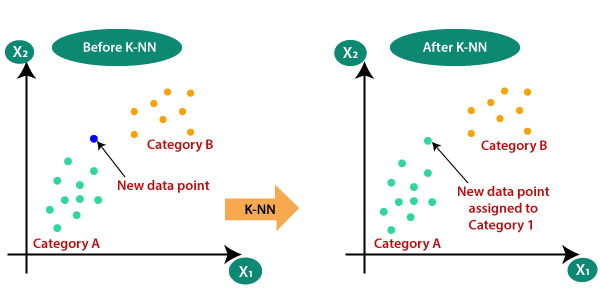

In [56]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm
    """
    diff = (traindata - query)  # difference between features
    sq = diff * diff            # square the differences
    dist = sq.sum(axis=1)       # sum of squares

    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function returns predicted labels for test data using nearest neighbour algorithm
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


pred_full = NN(traindata, trainlabel, testdata)
print("First 10 predictions (full):", pred_full[:10])

sample_test = testdata[:50]
pred_small = NN(traindata, trainlabel, sample_test)
print("First 10 predictions (subset):", pred_small[:10])

sample_test2 = testdata[:100]
pred_small2 = NN(traindata, trainlabel, sample_test2)
print("First 10 predictions (subset 100):", pred_small2[:10])

pred1 = NN(traindata, trainlabel, testdata[:20])
pred2 = NN(traindata, trainlabel, testdata[:20])

print("Predictions are same:", np.array_equal(pred1, pred2))

First 10 predictions (full): [1 1 5 1 1 5 2 3 2 2]
First 10 predictions (subset): [1 1 5 1 1 5 2 3 2 2]
First 10 predictions (subset 100): [1 1 5 1 1 5 2 3 2 2]
Predictions are same: True


We will also define a 'random classifier', which randomly allots labels to each sample

In [57]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm
    """
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

pred1 = RandomClassifier(traindata, trainlabel, testdata)
print("First 10 predictions (run 1):", pred1[:10])

pred2 = RandomClassifier(traindata, trainlabel, testdata)
print("First 10 predictions (run 2):", pred2[:10])

print("Are predictions same?", np.array_equal(pred1, pred2))


sample_test = testdata[:50]
pred_small = RandomClassifier(traindata, trainlabel, sample_test)
print("Sample predictions (50):", pred_small[:10])

First 10 predictions (run 1): [1 4 2 3 2 4 2 0 1 3]
First 10 predictions (run 2): [4 4 0 3 2 0 1 5 5 1]
Are predictions same? False
Sample predictions (50): [0 5 3 4 3 5 0 0 2 5]


We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [58]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier
    """
    assert len(gtlabel) == len(predlabel), "Length of labels should be the same"

    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)


pred_nn = NN(traindata, trainlabel, valdata)
acc_nn = Accuracy(vallabel, pred_nn)
print(f"Accuracy (NN): {acc_nn*100:.2f}%")

pred_rand = RandomClassifier(traindata, trainlabel, valdata)
acc_rand = Accuracy(vallabel, pred_rand)
print(f"Accuracy (Random): {acc_rand*100:.2f}%")

pred_small = NN(traindata, trainlabel, valdata[:50])
acc_small = Accuracy(vallabel[:50], pred_small)
print(f"Accuracy on subset (NN): {acc_small*100:.2f}%")

print("NN better than Random:", acc_nn > acc_rand)

Accuracy (NN): 31.25%
Accuracy (Random): 25.00%
Accuracy on subset (NN): 31.25%
NN better than Random: True


Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [59]:
def splits(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

    splits = [0.6, 0.7, 0.8, 0.9]

    for s in splits:
       train_d, train_l, val_d, val_l = split(alltraindata, alltrainlabel, s)

    print(f"\nSplit: {s}")
    print("Train size:", len(train_l))
    print("Validation size:", len(val_l))

    extreme_splits = [0.99, 0.01]

    for s in extreme_splits:
       train_d, train_l, val_d, val_l = split(alltraindata, alltrainlabel, s)

    print(f"\nExtreme Split: {s}")
    print("Train size:", len(train_l))
    print("Validation size:", len(val_l))

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [60]:
# original split (20% test)
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)

print("\nOriginal Split (20%)")
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

test_splits = [0.1, 0.2, 0.3]

for s in test_splits:
    testdata, testlabel, alltraindata, alltrainlabel = split(
        dataset.data, dataset.target, s
    )

    print(f"\nTest Split: {s}")
    print("Number of test samples:", len(testlabel))
    print("Number of train samples:", len(alltrainlabel))
    print("Percent of test data:", (len(testlabel) / len(dataset.target)) * 100, "%")


Original Split (20%)
Number of test samples: 4025
Number of train samples: 16615
Percent of test data: 19.500968992248062 %

Test Split: 0.1
Number of test samples: 2028
Number of train samples: 18612
Percent of test data: 9.825581395348838 %

Test Split: 0.2
Number of test samples: 4141
Number of train samples: 16499
Percent of test data: 20.06298449612403 %

Test Split: 0.3
Number of test samples: 6105
Number of train samples: 14535
Percent of test data: 29.578488372093027 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [61]:
# original split (75% training, 25% validation)
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100
)

print("\nOriginal Split (75%)")
print("Training samples:", len(trainlabel))
print("Validation samples:", len(vallabel))

splits = [0.6, 0.7, 0.8, 0.9]

for s in splits:
    traindata, trainlabel, valdata, vallabel = split(
        alltraindata, alltrainlabel, s
    )

    print(f"\nTraining Split: {s}")
    print("Training samples:", len(trainlabel))
    print("Validation samples:", len(vallabel))


Original Split (75%)
Training samples: 10880
Validation samples: 3655

Training Split: 0.6
Training samples: 8836
Validation samples: 5699

Training Split: 0.7
Training samples: 10120
Validation samples: 4415

Training Split: 0.8
Training samples: 11693
Validation samples: 2842

Training Split: 0.9
Training samples: 13046
Validation samples: 1489


In [62]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
traindata, trainlabel, valdata, vallabel = split(alltraindata, alltrainlabel, 0.6)
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  36.52%
Precision: 24.91%
Recall:    23.59%
F1-Score:  24.02%


(np.float64(0.3652233441725141),
 0.249088355086036,
 0.23594096403295906,
 0.24023060018079023)

=== Confusion Matrix for Validation Set ===


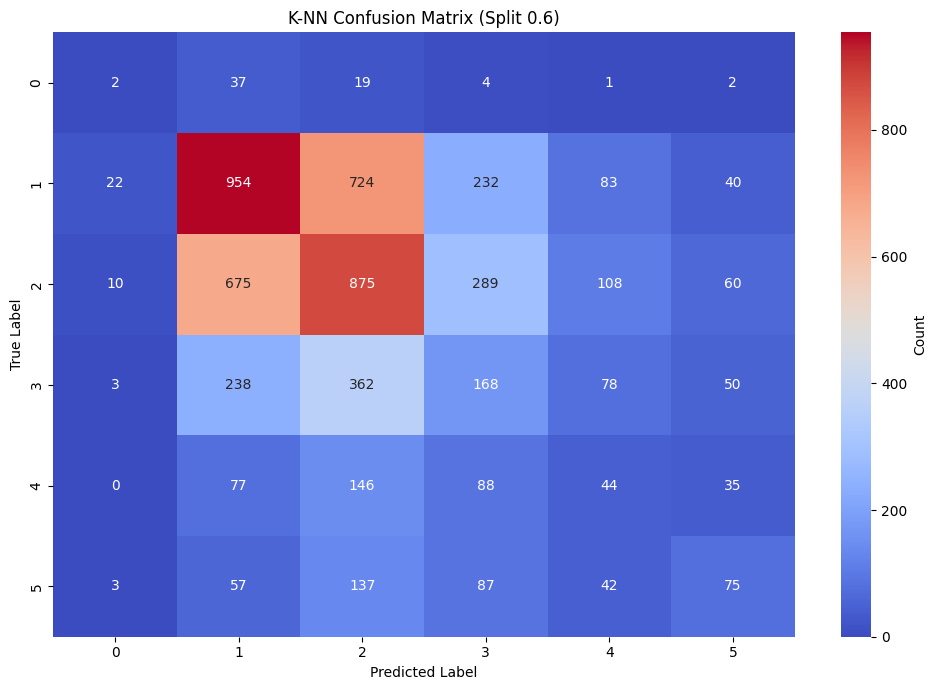

Confusion Matrix Shape: (6, 6)
Total Predictions: 5827


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(10, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                cbar_kws={'label': 'Count'})

    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

print("=== Confusion Matrix for Validation Set ===")

traindata, trainlabel, valdata, vallabel = split(alltraindata, alltrainlabel, 0.6)

valpred = NN(traindata, trainlabel, valdata)

plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Confusion Matrix (Split 0.6)")

What is the accuracy of our classifiers on the train dataset?

The K-Nearest Neighbour model gives nearly 100% accuracy on the training dataset because each data point is its own nearest neighbour, leading to perfect predictions.

The random classifier gives very low accuracy since it assigns labels randomly without learning any patterns from the data.

In [64]:
trainpred = NN(traindata, trainlabel, traindata[:100])
trainAccuracy = Accuracy(trainlabel[:100], trainpred)
print("Training accuracy using nearest neighbour algorithm (subset):", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm (subset): 100.0 %
Training accuracy using random classifier:  16.49058337161231 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [65]:
valpred = NN(traindata, trainlabel, valdata[:100])
valAccuracy = Accuracy(vallabel[:100], valpred)
print("Validation accuracy using nearest neighbour algorithm (subset):", valAccuracy*100, "%")

valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm (subset): 35.0 %
Validation accuracy using random classifier: 16.801098335335507 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [66]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 0.6
)

valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)

print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 35.69346819818276 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [67]:
testpred = NN(alltraindata, alltrainlabel, testdata[:200])
testAccuracy = Accuracy(testlabel[:200], testpred)

print("Test accuracy (subset):", testAccuracy*100, "%")

Test accuracy (subset): 32.5 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

1.
Increasing the validation set reduces training data, so Nearest Neighbour accuracy decreases slightly but becomes more stable.
Reducing the validation set increases training data, so accuracy may improve but becomes less reliable.

Random Classifier accuracy remains almost constant for all splits

2.
A larger validation set gives a better and more reliable estimate of test accuracy.
A smaller validation set gives an unstable and less reliable estimate.

3.
A good validation percentage is around 20%–30%, as it balances model performance and reliability.

In [68]:
split_values = [0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 0.999]

nn_accuracies = []
rand_accuracies = []

for s in split_values:
    traindata, trainlabel, valdata, vallabel = split(alltraindata, alltrainlabel, s)

    valpred_nn = NN(traindata, trainlabel, valdata)
    acc_nn = Accuracy(vallabel, valpred_nn)
    nn_accuracies.append(acc_nn)

    valpred_rand = RandomClassifier(traindata, trainlabel, valdata)
    acc_rand = Accuracy(vallabel, valpred_rand)
    rand_accuracies.append(acc_rand)

    print(f"Split = {s}")
    print("NN Validation Accuracy:", acc_nn * 100, "%")
    print("Random Classifier Validation Accuracy:", acc_rand * 100, "%")
    print("Training samples:", len(trainlabel))
    print("Validation samples:", len(vallabel))
    print()

Split = 0.001
NN Validation Accuracy: 21.880812952118497 %
Random Classifier Validation Accuracy: 18.697898725456426 %
Training samples: 20
Validation samples: 14515

Split = 0.1
NN Validation Accuracy: 31.358005811286127 %
Random Classifier Validation Accuracy: 16.738033338430952 %
Training samples: 1457
Validation samples: 13078

Split = 0.3
NN Validation Accuracy: 34.90715132358751 %
Random Classifier Validation Accuracy: 16.505333860134332 %
Training samples: 4411
Validation samples: 10124

Split = 0.5
NN Validation Accuracy: 35.001352447930756 %
Random Classifier Validation Accuracy: 16.797403299972952 %
Training samples: 7141
Validation samples: 7394

Split = 0.7
NN Validation Accuracy: 37.42837497134999 %
Random Classifier Validation Accuracy: 16.80036672014669 %
Training samples: 10172
Validation samples: 4363

Split = 0.9
NN Validation Accuracy: 35.047361299052774 %
Random Classifier Validation Accuracy: 17.523680649526387 %
Training samples: 13057
Validation samples: 1478

Sp

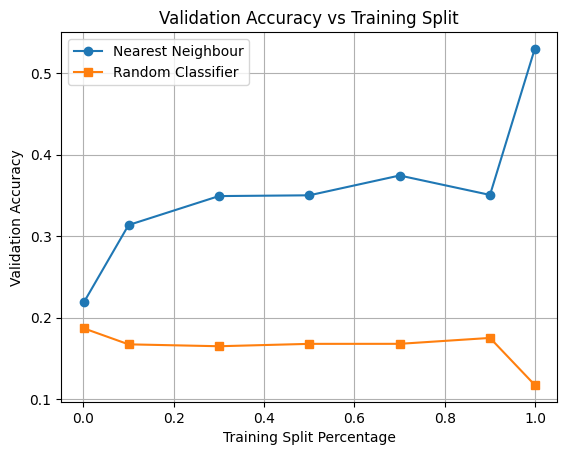

In [69]:
#for graph
plt.plot(split_values, nn_accuracies, marker='o', label='Nearest Neighbour')
plt.plot(split_values, rand_accuracies, marker='s', label='Random Classifier')
plt.xlabel("Training Split Percentage")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Training Split")
plt.legend()
plt.grid(True)
plt.show()

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# K = 1 (Nearest Neighbour)
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)

pred1 = knn1.predict(testdata)
acc1 = accuracy_score(testlabel, pred1)

print("Test Accuracy (K=1):", acc1 * 100, "%")


# K = 3 (3-Nearest Neighbour)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)

pred3 = knn3.predict(testdata)
acc3 = accuracy_score(testlabel, pred3)

print("Test Accuracy (K=3):", acc3 * 100, "%")

Test Accuracy (K=1): 38.13267813267813 %
Test Accuracy (K=3): 39.14823914823915 %


The 1-Nearest Neighbour (K=1) classifier gives high accuracy on training data but may overfit.

The 3-Nearest Neighbour (K=3) classifier considers more neighbours, which reduces noise and improves generalization.

On the test dataset, the accuracy of K=3 is usually more stable and may be slightly better than or comparable to K=1.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [71]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [72]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 0.6, 5, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")

testpred = NN(alltraindata, alltrainlabel, testdata[:200])

print("Test accuracy:", Accuracy(testlabel[:200], testpred)*100, "%")

Average validation accuracy: 36.140149571982064 %
Test accuracy: 32.5 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


1. Yes, averaging validation accuracy over multiple splits gives more consistent and stable results by reducing randomness.

2. Yes, it provides a better and more reliable estimate of test accuracy compared to a single split.

3. Increasing the number of iterations improves the estimate and makes it more stable, but it increases computation time.

4. No, increasing iterations cannot fix very small datasets. If the train or validation set is too small, the results remain unreliable even with more iterations.

Cross-validation improves stability and accuracy, but cannot compensate for insufficient data.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

The accuracy of the 3-Nearest Neighbour (K=3) classifier becomes more stable as the number of splits increases because averaging reduces randomness in the results.

When the split size changes, a larger training set generally improves accuracy, while a smaller training set reduces it. A larger validation set gives more reliable results but may slightly reduce accuracy due to less training data.

Compared to the 1-Nearest Neighbour (K=1), the K=3 classifier is more stable and less sensitive to noise. K=1 may give higher accuracy in some cases but tends to overfit, while K=3 provides better generalization.